# M1 — Exploración Interactiva: Modelos de Espacio de Estados y Núcleos de Markov

Este notebook acompaña las notas preliminares `m1_preliminar.md`. Antes de leer Chopin, experimenta con los conceptos clave.

## Objetivos
1. Simular un proceso AR(1) y verificar sus propiedades estacionarias
2. Entender el núcleo de transición como generalización de la matriz de transición
3. Construir un modelo de espacio de estados y observar estados vs observaciones
4. Visualizar el problema de filtrado: ¿cómo recupero el estado si solo veo las observaciones?

In [8]:
import sys, os
# Ensure project root is on the path for imports
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname('__file__'), '..')))

import numpy as np
import matplotlib.pyplot as plt
from src.ssm.models import AR1Process, LinearGaussianSSM
from src.ssm.kernels import gaussian_kernel, normalize_kernel

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
plt.style.use('dark_background')
print('Imports OK — modules loaded successfully')

Imports OK — modules loaded successfully


## 1. Proceso AR(1): Simulación y propiedades estacionarias

Recordemos: $X_t = \phi \cdot X_{t-1} + \sigma \cdot \varepsilon_t$

Si $|\phi| < 1$, el proceso es **estacionario** con:
- Media: $E[X_t] = 0$
- Varianza: $\text{Var}(X_t) = \frac{\sigma^2}{1 - \phi^2}$

Experimenta cambiando `phi` y `sigma` para ver cómo cambia la trayectoria.

Media muestral: -0.0780 (teórica: 0)
Varianza muestral: 4.0760 (teórica: 5.2632)


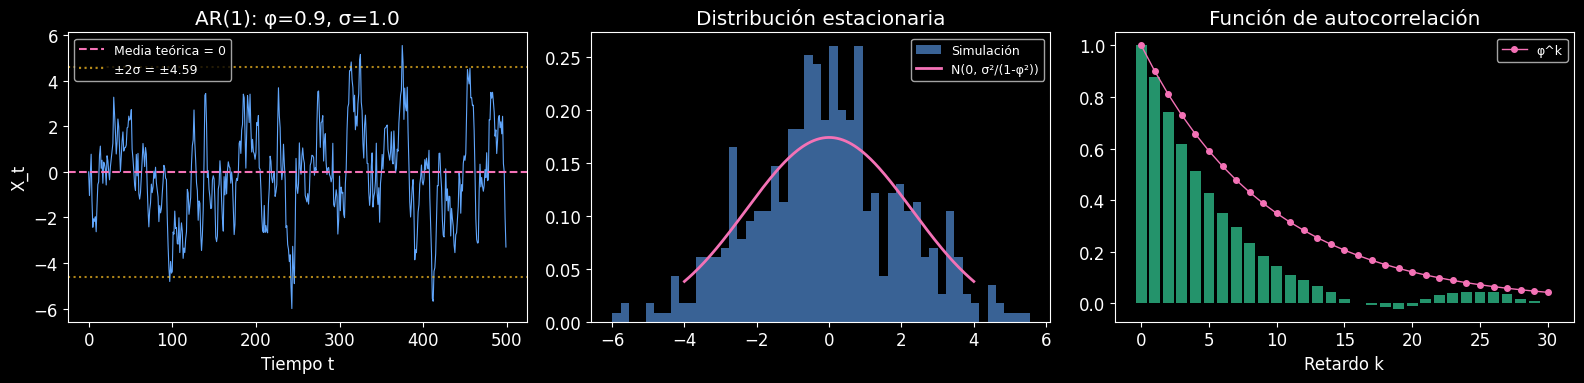

In [9]:
phi = 0.9
sigma = 1.0
n_steps = 500

ar1 = AR1Process(phi=phi, sigma=sigma)
rng = np.random.default_rng(42)
states = ar1.simulate(n_steps=n_steps, x0=0.0, rng=rng)

theo_mean = 0
theo_var = sigma**2 / (1 - phi**2)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1) Trayectoria
axes[0].plot(states, color='#60a5fa', linewidth=0.8)
axes[0].axhline(y=theo_mean, color='#f472b6', linestyle='--', label=f'Media teórica = {theo_mean}')
axes[0].axhline(y=2*np.sqrt(theo_var), color='#fbbf24', linestyle=':', alpha=0.7, label=f'±2σ = ±{2*np.sqrt(theo_var):.2f}')
axes[0].axhline(y=-2*np.sqrt(theo_var), color='#fbbf24', linestyle=':', alpha=0.7)
axes[0].set_title(f'AR(1): φ={phi}, σ={sigma}')
axes[0].set_xlabel('Tiempo t')
axes[0].set_ylabel('X_t')
axes[0].legend(fontsize=9)

# 2) Histograma vs densidad teórica
axes[1].hist(states, bins=50, density=True, color='#60a5fa', alpha=0.6, label='Simulación')
x_grid = np.linspace(-4*sigma, 4*sigma, 200)
theo_pdf = gaussian_kernel(x_prev=0, sigma=np.sqrt(theo_var), x_curr=x_grid)
axes[1].plot(x_grid, theo_pdf, color='#f472b6', linewidth=2, label='N(0, σ²/(1-φ²))')
axes[1].set_title('Distribución estacionaria')
axes[1].legend(fontsize=9)

# 3) Función de autocorrelación
from statsmodels.tsa.stattools import acf
acf_vals = acf(states, nlags=30)
axes[2].bar(range(31), acf_vals, color='#34d399', alpha=0.7)
theo_acf = [phi**k for k in range(31)]
axes[2].plot(range(31), theo_acf, color='#f472b6', marker='o', markersize=4, linewidth=1, label=f'φ^k')
axes[2].set_title('Función de autocorrelación')
axes[2].set_xlabel('Retardo k')
axes[2].legend(fontsize=9)

plt.tight_layout()
print(f'Media muestral: {np.mean(states):.4f} (teórica: {theo_mean})')
print(f'Varianza muestral: {np.var(states):.4f} (teórica: {theo_var:.4f})')

### Ejercicio: Efecto de φ

Cambia `phi` a diferentes valores y observa:
- `phi = 0.0`: Ruido blanco puro (sin memoria)
- `phi = 0.5`: Memoria moderada
- `phi = 0.95`: Memoria larga (caminata casi-aleatoria)
- `phi = -0.9`: Oscilaciones (memoria negativa)

**Pregunta:** ¿Qué pasa con la varianza estacionaria cuando φ → 1?

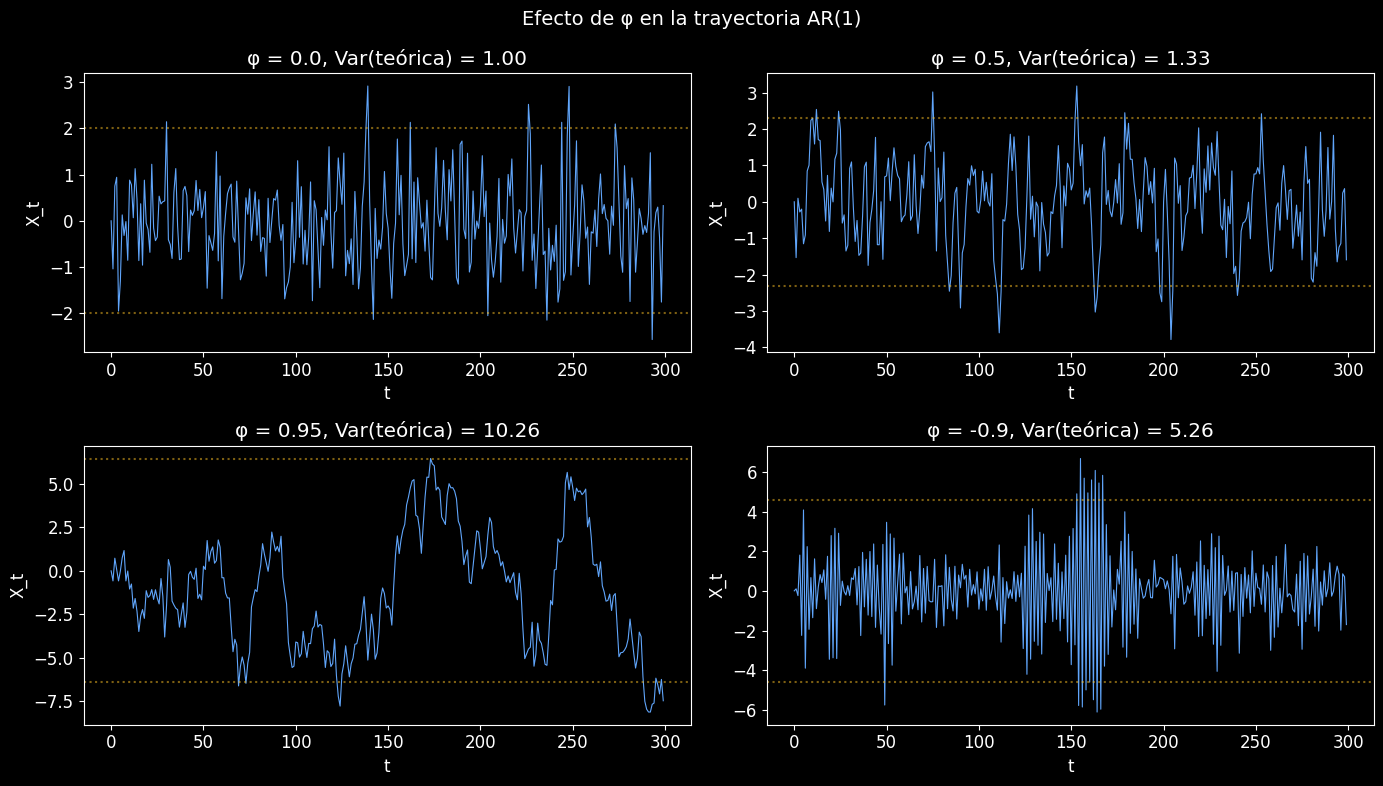

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
phis = [0.0, 0.5, 0.95, -0.9]
rng = np.random.default_rng(42)

for ax, phi in zip(axes.flat, phis):
    ar1 = AR1Process(phi=phi, sigma=1.0)
    s = ar1.simulate(n_steps=300, x0=0.0, rng=rng)
    theo_var = 1.0 / (1 - phi**2)
    ax.plot(s, color='#60a5fa', linewidth=0.8)
    ax.axhline(y=2*np.sqrt(theo_var), color='#fbbf24', linestyle=':', alpha=0.5)
    ax.axhline(y=-2*np.sqrt(theo_var), color='#fbbf24', linestyle=':', alpha=0.5)
    ax.set_title(f'φ = {phi}, Var(teórica) = {theo_var:.2f}')
    ax.set_xlabel('t')
    ax.set_ylabel('X_t')

plt.suptitle('Efecto de φ en la trayectoria AR(1)', fontsize=14)
plt.tight_layout()

## 2. Núcleo de transición: De matrices a funciones

En una **cadena de Markov discreta**, tienes una matriz P donde P(i,j) = P(X_{t+1}=j | X_t=i).

En un **proceso AR(1)**, la transición es una densidad gaussiana:

$$K(x_{prev}, x_{curr}) = \mathcal{N}(x_{curr};\, \phi \cdot x_{prev},\, \sigma^2)$$

Experimenta: mueve `x_prev` y observa cómo el pico del núcleo se desplaza.

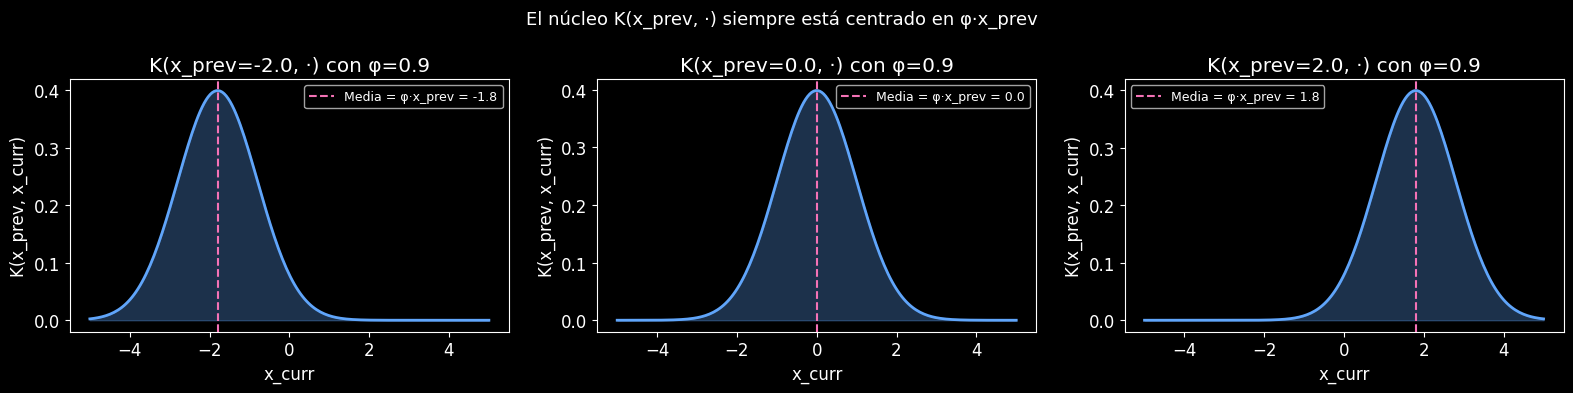

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
x_grid = np.linspace(-5, 5, 200)

phi_val = 0.9
sigma_val = 1.0

for i, x_prev in enumerate([-2.0, 0.0, 2.0]):
    kernel_vals = [gaussian_kernel(x_prev=x_prev, sigma=sigma_val, x_curr=x, phi=phi_val) for x in x_grid]
    axes[i].fill_between(x_grid, kernel_vals, color='#60a5fa', alpha=0.3)
    axes[i].plot(x_grid, kernel_vals, color='#60a5fa', linewidth=2)
    mean = phi_val * x_prev
    axes[i].axvline(x=mean, color='#f472b6', linestyle='--', label=f'Media = φ·x_prev = {mean:.1f}')
    axes[i].set_title(f'K(x_prev={x_prev}, ·) con φ={phi_val}')
    axes[i].set_xlabel('x_curr')
    axes[i].set_ylabel('K(x_prev, x_curr)')
    axes[i].legend(fontsize=9)

plt.suptitle('El núcleo K(x_prev, ·) siempre está centrado en φ·x_prev', fontsize=13)
plt.tight_layout()

## 3. Modelo de Espacio de Estados: Estados ocultos vs observaciones

Un SSM tiene:
- **Estado oculto:** $X_t = \phi \cdot X_{t-1} + \sigma_v \cdot v_t$ (lo que NO vemos)
- **Observación:** $Y_t = X_t + \sigma_w \cdot w_t$ (lo que SÍ vemos)

El **problema de filtrado** es: dado $Y_{1:t}$, ¿cuál es la distribución de $X_t$?

SNR = σ_trans/σ_obs = 0.30
Las observaciones son ruidosas. El filtro de Kalman (M2) nos ayudará a recuperar X_t.


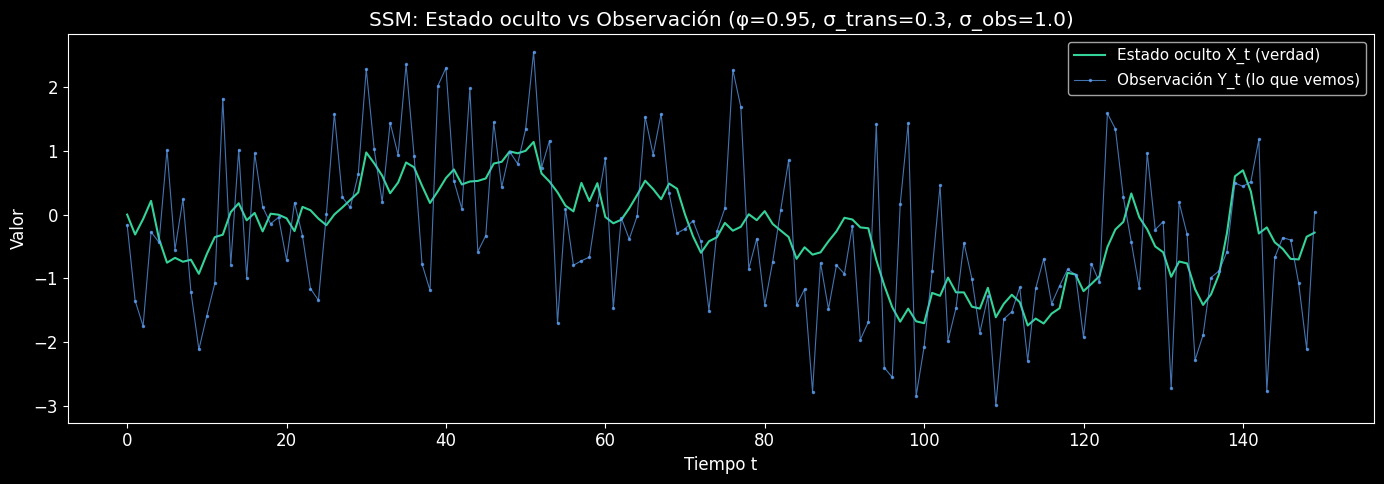

In [12]:
ssm = LinearGaussianSSM(transition_phi=0.95, transition_sigma=0.3, observation_sigma=1.0)
rng = np.random.default_rng(42)
states, observations = ssm.simulate(n_steps=150, x0=0.0, rng=rng)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(states, color='#34d399', linewidth=1.5, label='Estado oculto X_t (verdad)')
ax.plot(observations, color='#60a5fa', linewidth=0.8, alpha=0.7, marker='.', markersize=3, label='Observación Y_t (lo que vemos)')
ax.set_title('SSM: Estado oculto vs Observación (φ=0.95, σ_trans=0.3, σ_obs=1.0)')
ax.set_xlabel('Tiempo t')
ax.legend(fontsize=11)
ax.set_ylabel('Valor')
plt.tight_layout()

print(f'SNR = σ_trans/σ_obs = {0.3/1.0:.2f}')
print(f'Las observaciones son ruidosas. El filtro de Kalman (M2) nos ayudará a recuperar X_t.')

### Ejercicio: Efecto del ruido de observación

Cambia `observation_sigma` y observa:
- `0.1`: Observaciones casi perfectas — fácil recuperar el estado
- `1.0`: Mucho ruido — necesitas un buen filtro
- `3.0`: Ruido domina la señal — ¿se puede recuperar algo?

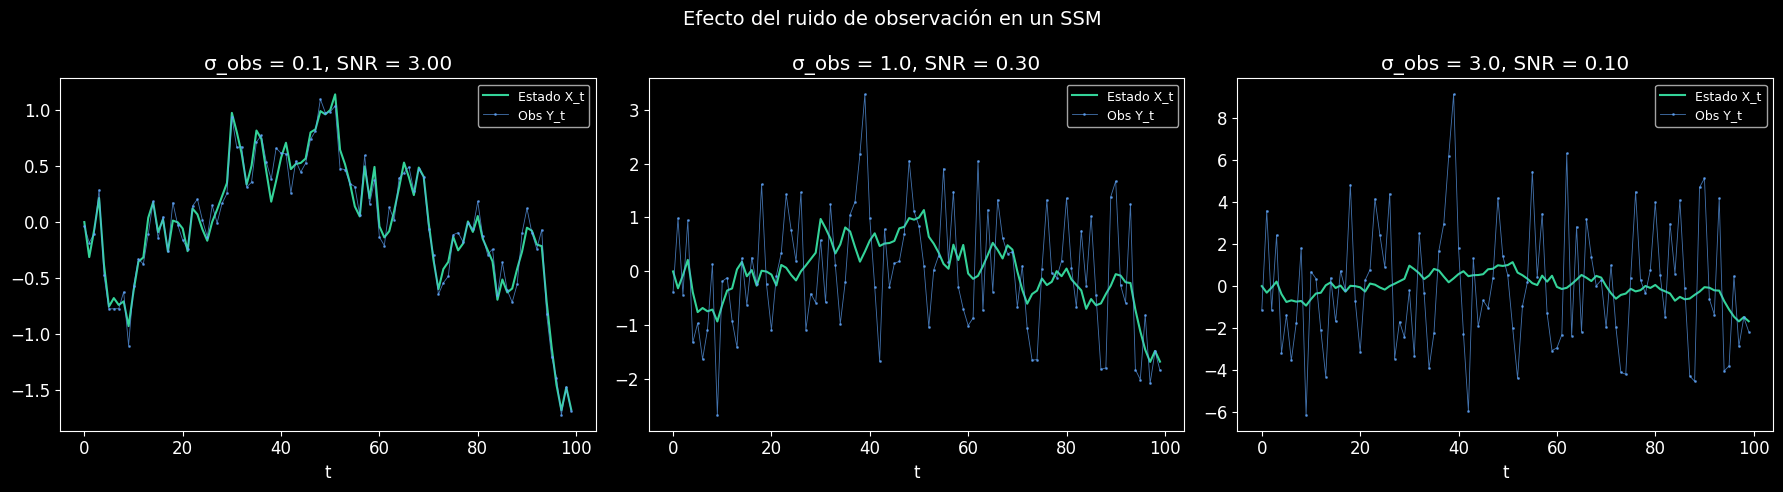

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
obs_sigmas = [0.1, 1.0, 3.0]

for ax, obs_sigma in zip(axes, obs_sigmas):
    ssm = LinearGaussianSSM(transition_phi=0.95, transition_sigma=0.3, observation_sigma=obs_sigma)
    rng = np.random.default_rng(42)
    states, obs = ssm.simulate(n_steps=100, x0=0.0, rng=rng)
    ax.plot(states, color='#34d399', linewidth=1.5, label='Estado X_t')
    ax.plot(obs, color='#60a5fa', linewidth=0.6, marker='.', markersize=2, alpha=0.7, label='Obs Y_t')
    ax.set_title(f'σ_obs = {obs_sigma}, SNR = {0.3/obs_sigma:.2f}')
    ax.legend(fontsize=9)
    ax.set_xlabel('t')

plt.suptitle('Efecto del ruido de observación en un SSM', fontsize=14)
plt.tight_layout()

## 4. El problema de filtrado

Queremos calcular $p(X_t | Y_{1:t})$ — la distribución del estado dado todo lo que hemos observado.

En el caso lineal-Gaussiano, la **solución exacta** es el **filtro de Kalman** (M2).

Por ahora, una intuición visual: si el ruido de observación es pequeño, las observaciones están cerca del estado. Si es grande, necesitamos un filtro más sofisticado.

**Pregunta para M2:** ¿Cómo combinamos la predicción del modelo (el núcleo K) con la observación para actualizar nuestra creencia sobre X_t?

La media móvil es un filtro ingenuo. El filtro de Kalman (M2) será mucho mejor.


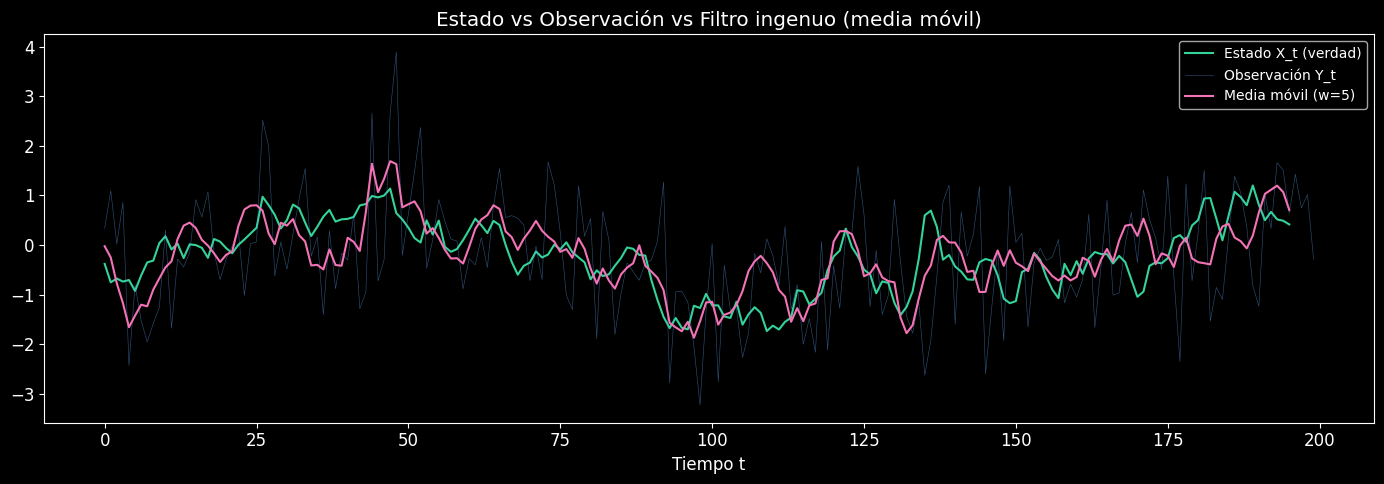

: 

In [ ]:
# Un primer intento ingenuo: la media móvil como "filtro aproximado"
ssm = LinearGaussianSSM(transition_phi=0.95, transition_sigma=0.3, observation_sigma=1.0)
rng = np.random.default_rng(42)
states, obs = ssm.simulate(n_steps=200, x0=0.0, rng=rng)

window = 5
ma_filter = np.convolve(obs, np.ones(window)/window, mode='valid')
# ma_filter has length len(obs) - window + 1
ma_x = np.arange(len(ma_filter))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(states[window-1:], color='#34d399', linewidth=1.5, label='Estado X_t (verdad)')
ax.plot(obs, color='#60a5fa', linewidth=0.4, alpha=0.5, label='Observación Y_t')
ax.plot(ma_x, ma_filter, color='#f472b6', linewidth=1.5, label=f'Media móvil (w={window})')
ax.set_title('Estado vs Observación vs Filtro ingenuo (media móvil)')
ax.set_xlabel('Tiempo t')
ax.legend(fontsize=10)
plt.tight_layout()

print('La media móvil es un filtro ingenuo. El filtro de Kalman (M2) será mucho mejor.')

## Resumen

1. **Proceso AR(1)**: $X_t = \phi X_{t-1} + \sigma \varepsilon_t$. Estacionario si $|\phi| < 1$. Varianza $\sigma^2/(1-\phi^2)$.

2. **Núcleo de probabilidad**: Generalización de la matriz de transición. $K(x_{prev}, x_{curr})$ te dice la densidad de transición.

3. **SSM**: Estado oculto $X_t$ (Markov) + observación $Y_t$ (condicionalmente independiente dado $X_t$).

4. **Problema de filtrado**: Recuperar $X_t$ a partir de $Y_{1:t}$. El filtro de Kalman (M2) resuelve esto exactamente en el caso lineal-Gaussiano.

---

**Siguiente:** Lee Chopin Capítulos 2-4 con las notas `m1_preliminar.md` a mano. Después, el notebook de M2 implementará el filtro de Kalman.